In [1]:
#import data handling & visualization packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# preprocessing imports
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

In [3]:
# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
# Metrics
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [6]:
# import data set
df = pd.read_csv('Human Health.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Human Health.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258357 entries, 0 to 258356
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alx       258357 non-null  float64
 1   aly       258357 non-null  float64
 2   alz       258357 non-null  float64
 3   glx       258356 non-null  float64
 4   gly       258356 non-null  float64
 5   glz       258356 non-null  float64
 6   arx       258356 non-null  float64
 7   ary       258356 non-null  float64
 8   arz       258356 non-null  float64
 9   grx       258356 non-null  float64
 10  gry       258356 non-null  float64
 11  grz       258356 non-null  float64
 12  Activity  258356 non-null  float64
 13  subject   258356 non-null  object 
dtypes: float64(13), object(1)
memory usage: 27.6+ MB


In [ ]:
df.isnull().sum()

,0
alx,0
aly,0
alz,0
glx,1
gly,1
glz,1
arx,1
ary,1
arz,1
grx,1


In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Activity'>

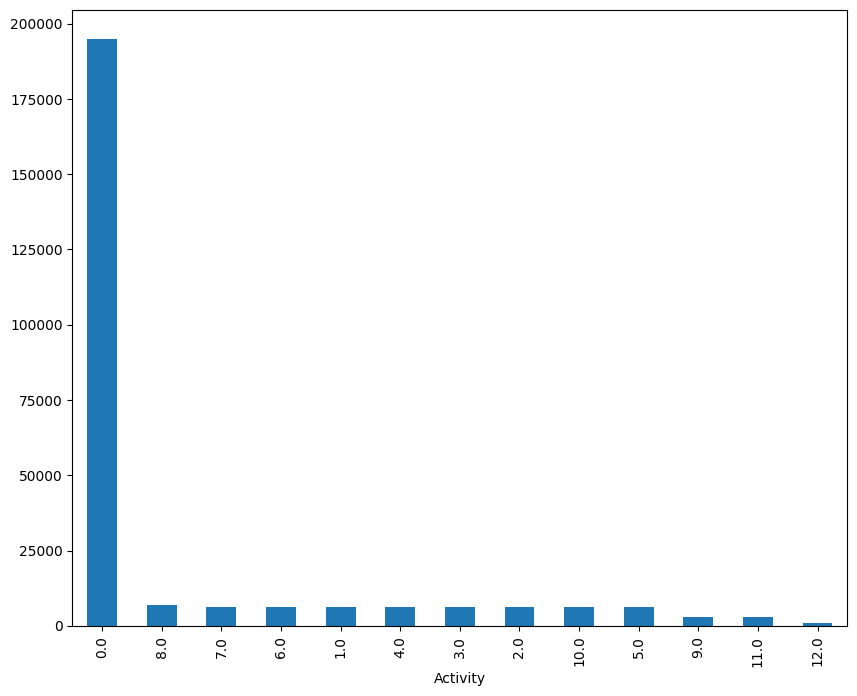

In [ ]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [ ]:
df = df[df["Activity"] != 0]

<Axes: xlabel='Activity'>

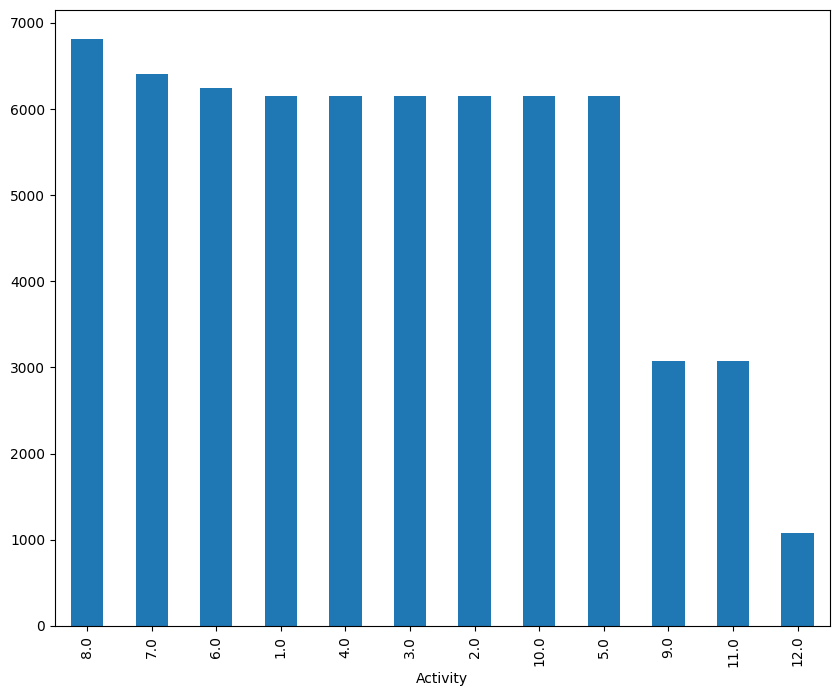

In [ ]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [ ]:
activity_label = {
1: "Standing still (1 min)",
2: "Sitting and relaxing (1 min)",
3: "Lying down (1 min)",
4: "Walking (1 min)",
5: "Climbing stairs (1 min)",
6: "Waist bends forward (20x)",
7: "Frontal elevation of arms (20x)",
8: "Knees bending (crouching) (20x)",
9: "Cycling (1 min)",
10: "Jogging (1 min)",
11: "Running (1 min)",
12: "Jump front & back (20x)"
  }

In [ ]:
subject1 = df[df["subject"] == 'subject1']
readings = ['a','g']

for i in range(1,12):
  for r in readings:
    print(f"\n\n============= {activity_label[i]} - {r} =============")
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
             color = "red", alpha = 0.7, label = r + "lx")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
             color = "blue", alpha = 0.7, label = r + "ly")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
             color = "green", alpha = 0.7, label = r + "lz")
    plt.title("Left Ankle sensor")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
             color = "red", alpha = 0.7, label = r + "rx")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
             color = "blue", alpha = 0.7, label = r + "ry")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
             color = "green", alpha = 0.7, label = r + "rz")
    plt.title("Right Wrist sensor")
    plt.legend()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df["Activity"] = df["Activity"].map(activity_label)

In [ ]:
df

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
6656,2.649300,-9.4517,0.37683,-0.20965,-0.88931,-0.50884,-2.8439,-9.0618,1.8177,-0.058824,-0.93429,-0.34483,Standing still (1 min),subject1
6657,2.415700,-9.5306,0.40179,-0.20965,-0.88931,-0.50884,-2.9935,-9.2048,1.5189,-0.058824,-0.93429,-0.34483,Standing still (1 min),subject1
6658,2.386500,-9.5991,0.48141,-0.20037,-0.86867,-0.50688,-2.8846,-9.1945,1.5507,-0.058824,-0.93429,-0.34483,Standing still (1 min),subject1
6659,2.375800,-9.5997,0.42919,-0.20037,-0.86867,-0.50688,-2.9245,-9.1746,1.5413,-0.078431,-0.93429,-0.34052,Standing still (1 min),subject1
6660,2.323900,-9.5406,0.40038,-0.20037,-0.86867,-0.50688,-2.8963,-9.2039,1.6127,-0.078431,-0.93429,-0.34052,Standing still (1 min),subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256508,7.250600,-14.4200,4.51820,0.55473,-0.78612,-0.25933,-6.3834,4.2868,5.6831,-0.343140,-0.35524,1.03880,Jogging (1 min),subject2
256509,0.152920,-16.0150,5.39870,0.55473,-0.78612,-0.25933,-5.5113,5.8742,5.4187,-0.454900,-0.26899,1.02800,Jogging (1 min),subject2
256510,-0.716640,-15.8480,3.30460,0.53803,-0.74672,-0.43026,-2.7821,8.1469,4.6886,-0.454900,-0.26899,1.02800,Jogging (1 min),subject2
256511,2.073700,-19.2120,5.50800,0.53803,-0.74672,-0.43026,-2.8655,8.8789,2.8919,-0.454900,-0.26899,1.02800,Jogging (1 min),subject2


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,63539.0,1.518006,4.163153,-22.07500,0.277865,1.360100,2.767300,20.02400
aly,63539.0,-8.690525,4.924639,-19.61900,-9.864450,-9.538600,-7.456400,21.16100
alz,63539.0,-1.146824,5.987430,-19.37300,-4.276400,0.170980,1.106650,25.01500
glx,63538.0,0.086248,0.471783,-1.42490,-0.361780,0.050093,0.512060,1.59180
gly,63538.0,-0.655650,0.377387,-2.20080,-0.844280,-0.759850,-0.645400,0.67730
glz,63538.0,-0.073395,0.492975,-2.38310,-0.499020,-0.121810,0.355600,1.22590
arx,63538.0,-3.913649,4.901580,-22.14800,-5.225825,-3.089800,-2.062025,19.68900
ary,63538.0,-5.321437,6.453688,-18.93200,-9.172000,-7.649200,-1.971800,21.83800
arz,63538.0,2.914624,3.657706,-18.22800,1.022800,2.340850,5.417000,25.19400
grx,63538.0,-0.351121,0.414270,-1.17060,-0.684310,-0.398040,-0.076471,0.92745


In [ ]:
df1 = df.copy()

# Select only the numerical columns for outlier removal
numerical_cols = df1.select_dtypes(include=np.number).columns

for feature in numerical_cols:
  lower_range = np.quantile(df1[feature], 0.01)
  upper_range = np.quantile(df1[feature], 0.99)

  df1 = df1.drop(df1[(df1[feature] > upper_range) | (df1[feature] < lower_range)].index, axis = 0)

df.shape, df1.shape

((63539, 14), (59808, 14))

In [ ]:
df1.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,59808.0,1.678819,2.787533,-18.37900,0.322425,1.37565,2.726025,14.75100
aly,59808.0,-8.624718,4.292157,-19.32300,-9.821700,-9.52885,-7.486200,1.85220
alz,59808.0,-0.831313,4.966466,-18.59400,-3.738750,0.28867,1.092425,9.05320
glx,59807.0,0.058140,0.468258,-1.42490,-0.369200,0.03525,0.504640,1.59180
gly,59807.0,-0.666567,0.370122,-2.20080,-0.848030,-0.77111,-0.662290,0.67730
glz,59807.0,-0.078786,0.496437,-2.38310,-0.502950,-0.12574,0.355600,1.22590
arx,59807.0,-3.903202,4.578800,-22.14800,-5.187050,-3.08800,-2.115000,19.51200
ary,59807.0,-5.369104,6.343864,-18.93200,-9.163350,-7.74510,-2.004050,21.79900
arz,59807.0,3.102145,3.461439,-18.22800,1.214450,2.47890,5.440350,25.19400
grx,59807.0,-0.342911,0.420212,-1.17060,-0.684310,-0.39020,-0.068627,0.92745


In [ ]:
le = LabelEncoder()
df1['Activity'] = le.fit_transform(df1['subject'])

df1['Activity'] = le.fit_transform(df1['Activity'])

In [ ]:
X = df1.drop(["Activity", "subject"], axis=1).values
y = df1['Activity'].values

In [ ]:
rs = RobustScaler().fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [ ]:
nan_mask = np.isnan(X_train).any(axis=1)
X_train_cleaned = X_train[~nan_mask]
y_train_cleaned = y_train[~nan_mask]

lr = LogisticRegression()
lr.fit(X_train_cleaned, y_train_cleaned)

lr.score(X_train_cleaned, y_train_cleaned), lr.score(X_test, y_test)

(0.7126518782744399, 0.7106741573033708)

In [ ]:
model_params = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs']
        }
    },
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']
        }
    },
    'SVC': {
        'model': SVC(),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    },
    'Random ForestClassifier': {
        'model': RandomForestClassifier(),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        }
    },
    'GaussianNB' : {
        'model' : GaussianNB(),
        'params' : {
            # GaussianNB typically doesn't have parameters to tune in this context
        }
    }
}

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

results = []

for model_name, mp in model_params.items():
  print(f"\n Running GridSearchCV for: {model_name}")

  pipe = Pipeline([
      ('imputer', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler()),
       ('model', mp['model'])
  ])
  clf = GridSearchCV(pipe, mp['params'], cv=5, n_jobs=-1, scoring='f1_weighted', verbose=1)
  clf.fit(X_train, y_train)

  print(f" Best params for {model_name}: {clf.best_params_}")
  print(f" Best cross-validation F1-score: {clf.best_score_:.4f}")
  y_pred = clf.predict(X_test)

  print(f"\n Classification Report for {model_name}:\n", classification_report(y_test, y_pred))

  results.append({
      'model': model_name,
      'best_params': clf.best_params_,
      'f1_score': clf.best_score_
  })


 Running GridSearchCV for: LogisticRegression
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


 Best params for LogisticRegression: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
 Best cross-validation F1-score: 0.7100

 Classification Report for LogisticRegression:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      8067
           1       0.71      0.63      0.67      6885

    accuracy                           0.71     14952
   macro avg       0.71      0.70      0.71     14952
weighted avg       0.71      0.71      0.71     14952


 Running GridSearchCV for: KNeighborsClassifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


 Best params for KNeighborsClassifier: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'distance'}
 Best cross-validation F1-score: 0.9980

 Classification Report for KNeighborsClassifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      8067
           1       1.00      1.00      1.00      6885

    accuracy                           1.00     14952
   macro avg       1.00      1.00      1.00     14952
weighted avg       1.00      1.00      1.00     14952


 Running GridSearchCV for: SVC
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
